# HQPINN DHO Notebook

This notebook presents a compact walkthrough of the **DHO** benchmark from *Hybrid Quantum Physics-informed Neural Network: Towards Efficient Learning of High-speed Flows*.

It is organized around five objectives:
- restate the governing equation and the DHO-specific PINN loss
- summarize the `HQPINN` two-branch methodology used in the paper
- record the training setup used for this reproduction
- compare three representative architecture variants: `cc`, `hy-m`, and `qq-m`
- inspect the final learned trajectories


In [56]:
from __future__ import annotations

import csv
import os
from pathlib import Path
import sys

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "HQPINN" / "configs").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from the current working directory.")


REPO_ROOT = resolve_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from HQPINN.config import (
    DHO_HIDDEN_WIDTH,
    DHO_LR,
    DHO_N_EPOCHS,
    DHO_N_SAMPLES,
    DHO_NUM_HIDDEN_LAYERS,
    DHO_PLOT_EVERY,
    DTYPE,
    K,
    LAMBDA1,
    LAMBDA2,
    M,
    MU,
    N_LAYERS,
)
from HQPINN.lib.DHO.core_dho import u_exact
from HQPINN.lib.runner import train_and_evaluate
from HQPINN.utils import make_time_grid

DHO_ROOT = REPO_ROOT / "HQPINN" / "lib" / "DHO"
SUMMARY_PATH = DHO_ROOT / "results" / "dho_summary.csv"
TARGET_MODELS = ["cc", "hy-m", "qq-m"]
TRAIN_CONFIGS = {
    "cc": REPO_ROOT / "HQPINN" / "configs" / "dho_cc_train.json",
    "hy-m": REPO_ROOT / "HQPINN" / "configs" / "dho_hy_m_train.json",
    "qq-m": REPO_ROOT / "HQPINN" / "configs" / "dho_qq_m_train.json",
}


def load_dho_rows(summary_path: Path) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []
    with summary_path.open(newline="", encoding="utf-8") as handle:
        for raw in csv.DictReader(handle):
            try:
                rows.append(
                    {
                        "run_id": raw["run_id"],
                        "model": raw["Model"],
                        "size": raw["Size"],
                        "params": int(raw["Trainable parameters"]),
                        "elapsed": float(raw["elapsed time (s)"]),
                        "rel_l2": float(raw["Relative L2 error"]),
                    }
                )
            except (KeyError, ValueError):
                continue
    return rows


def latest_runs_for_models(summary_path: Path, models: list[str]) -> list[dict[str, object]]:
    latest: dict[str, dict[str, object]] = {}
    for row in load_dho_rows(summary_path):
        model = str(row["model"])
        if model not in models:
            continue
        current = latest.get(model)
        if current is None or str(row["run_id"]) > str(current["run_id"]):
            latest[model] = row
    return [latest[model] for model in models if model in latest]


def final_png_for(model: str) -> Path | None:
    folder = DHO_ROOT / "results" / f"dho_{model.replace('-', '_')}"
    if not folder.exists():
        return None
    candidates = sorted(path for path in folder.glob("*.png") if "epoch-" not in path.name)
    return candidates[-1] if candidates else None


def family_color(model: str) -> str:
    return {
        "cc": "#4C78A8",
        "hy-m": "#F58518",
        "qq-m": "#54A24B",
    }[model]


def train_selected_models(force_retrain: bool = False) -> dict[str, dict[str, object]]:
    if not force_retrain:
        print("Training step skipped. The notebook will use the latest runs recorded in dho_summary.csv.")
        return {}

    results: dict[str, dict[str, object]] = {}
    for model in TARGET_MODELS:
        config_path = TRAIN_CONFIGS[model]
        print(f"Training {model} from scratch with {config_path.relative_to(REPO_ROOT)}")
        results[model] = train_and_evaluate(
            {
                "config_path": str(config_path),
                "shared_runner": {"force_retrain": True},
            },
            REPO_ROOT / "runs" / f"notebook-dho-{model}",
        )
    return results


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Governing Equation, PINN Loss, and HQPINN Structure

`DHO` corresponds to the introductory benchmark from **Appendix A.2** of the paper. Its governing equation is

$$
m u''(t) + \mu u'(t) + k u(t) = 0,
\qquad t \in (0, 1],
$$

with initial conditions

$$
u(0) = 1,
\qquad
u'(0) = 0.
$$

With the constants used here, $m=1$, $\mu=4$, and $k=400$, the exact solution is

$$
\omega = \sqrt{k - (\mu/2)^2},
\qquad
u_{\mathrm{exact}}(t) = e^{-\mu t/2}
\left(\cos(\omega t) + \frac{\mu}{2\omega}\sin(\omega t)\right).
$$

As noted in the project README, `DHO` uses a problem-specific PINN loss rather than the Euler-equation loss used in the other case studies. The objective implemented in the DHO scripts is

$$
\mathcal{L} = \mathcal{L}_{IC,u} + \lambda_1 \mathcal{L}_{IC,u'} + \lambda_2 \mathcal{L}_{PDE},
$$

with

$$
\mathcal{L}_{IC,u} = (u_\theta(0) - 1)^2,
\qquad
\mathcal{L}_{IC,u'} = (u_\theta'(0))^2,
$$

and

$$
\mathcal{L}_{PDE} = \frac{1}{N} \sum_i
\left(m u_\theta''(t_i) + \mu u_\theta'(t_i) + k u_\theta(t_i)\right)^2.
$$

The central methodological point of `HQPINN` is the use of **two parallel branches** fed by the same input and combined by a trainable linear fusion layer. In compact form,

$$
u_\theta(t) = g_{\mathrm{fuse}}\big(b_1(t), b_2(t)\big).
$$

The retained architecture variants instantiate this principle as follows:
- `cc`: classical-classical, with two parallel MLP branches
- `hy-m`: hybrid Merlin, with one interferometric quantum branch and one classical branch
- `qq-m`: quantum-quantum Merlin, with two interferometric quantum branches

In the language of the README, the quantum component is a parameterized quantum circuit (`PQC`) alternating feature-map layers and trainable ansatz layers. For the DHO case, the Merlin branches use the harmonic angle encoding

$$
\phi(t) = (\pi t, 2\pi t, 3\pi t),
$$

followed by trainable interferometric layers and a scalar fusion readout.

This notebook retains the Merlin variants rather than the PennyLane variants because the PennyLane gate-model implementation is substantially slower in an interactive notebook setting. Merlin preserves the same `HQPINN` branch structure while keeping training times compatible with notebook use.


In [57]:
t_train = make_time_grid()

print("DHO benchmark constants")
print("-" * 72)
print(f"m={M}, mu={MU}, k={K}")
print()
print("Reproduction setup")
print("-" * 72)
print(f"optimizer                : Adam")
print(f"learning rate            : {DHO_LR}")
print(f"epochs                   : {DHO_N_EPOCHS}")
print(f"plot/log frequency       : every {DHO_PLOT_EVERY} epochs")
print(f"time grid points in [0,1]: {DHO_N_SAMPLES}")
print(f"interior training points : {int(t_train.shape[0])} (t=0 excluded)")
print(f"loss weights             : lambda1={LAMBDA1}, lambda2={LAMBDA2}")
print(f"dtype                    : {DTYPE}")
print()
print("Retained architecture variants")
print("-" * 72)
print(
    f"cc   : classical-classical, each branch with {DHO_NUM_HIDDEN_LAYERS} hidden layers and width {DHO_HIDDEN_WIDTH}"
)
print(
    f"hy-m : hybrid Merlin, one quantum branch with {N_LAYERS} quantum layers + one classical branch with {DHO_NUM_HIDDEN_LAYERS} hidden layers and width {DHO_HIDDEN_WIDTH}"
)
print(f"qq-m : quantum-quantum Merlin, each branch with {N_LAYERS} quantum layers")
print("Merlin photon setting    : n_photons = 1 for the retained DHO experiments")


DHO benchmark constants
------------------------------------------------------------------------
m=1.0, mu=4.0, k=400.0

Reproduction setup
------------------------------------------------------------------------
optimizer                : Adam
learning rate            : 0.002
epochs                   : 1801
plot/log frequency       : every 100 epochs
time grid points in [0,1]: 200
interior training points : 199 (t=0 excluded)
loss weights             : lambda1=0.1, lambda2=0.0001
dtype                    : torch.float64

Retained architecture variants
------------------------------------------------------------------------
cc   : classical-classical, each branch with 2 hidden layers and width 16
hy-m : hybrid Merlin, one quantum branch with 3 quantum layers + one classical branch with 2 hidden layers and width 16
qq-m : quantum-quantum Merlin, each branch with 3 quantum layers
Merlin photon setting    : n_photons = 1 for the retained DHO experiments


## 2. Exact Reference Solution

Because `DHO` predicts a single damped trajectory, the benchmark is convenient for compact visual comparison.
The curve below is the exact reference solution used as the baseline in the later comparisons.


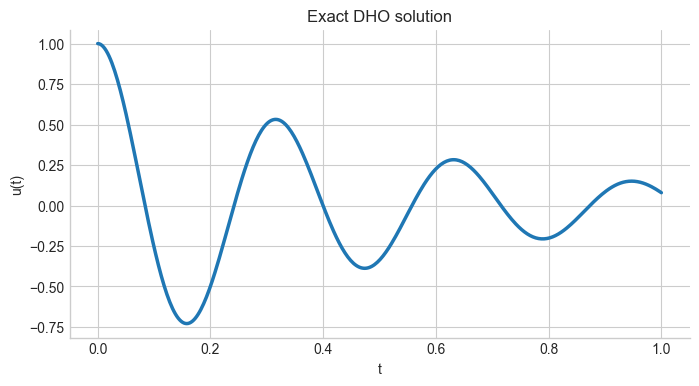

In [58]:
t = np.linspace(0.0, 1.0, 400)
u = u_exact(t)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, u, color="#1f77b4", linewidth=2.5)
ax.set_title("Exact DHO solution")
ax.set_xlabel("t")
ax.set_ylabel("u(t)")
plt.show()


## 3. Optional Training Step

This section can launch fresh training runs for the same three representative variants used throughout the comparison.

- `cc`: classical-classical baseline
- `hy-m`: hybrid Merlin variant
- `qq-m`: quantum-quantum Merlin variant

Unless explicitly enabled, the training step is skipped so that the notebook remains lightweight and the following sections rely on the latest saved runs.
Set `force_retrain=True` to regenerate the benchmark results from scratch.


In [59]:
# Set to True to rerun training from scratch.
training_results = train_selected_models(force_retrain=False)


Training step skipped. The notebook will use the latest runs recorded in dho_summary.csv.


## 4. Paper-Facing Metrics

The following summary quantities provide the clearest compact comparison for the DHO benchmark:
- **Relative L2 error** measures agreement with the exact trajectory
- **Trainable parameters** summarize model size
- **Learning time** summarizes practical optimization cost

The following cell reads the latest available run for each retained variant from `dho_summary.csv`.


Latest DHO runs used in this notebook
----------------------------------------------------------------------------------------
   model |     size |     params |       rel_l2 |     time_s |          run_id
----------------------------------------------------------------------------------------
      cc |     16-2 |        721 |   4.1599e-01 |       2.81 | 20260403-175734
    hy-m |   16-2-1 |        423 |   3.9378e-01 |      80.80 | 20260402-183448
    qq-m |        1 |        197 |   1.3937e-01 |     195.16 | 20260402-200057

Lowest relative L2 error : qq-m
Smallest model            : qq-m
Fastest training          : cc


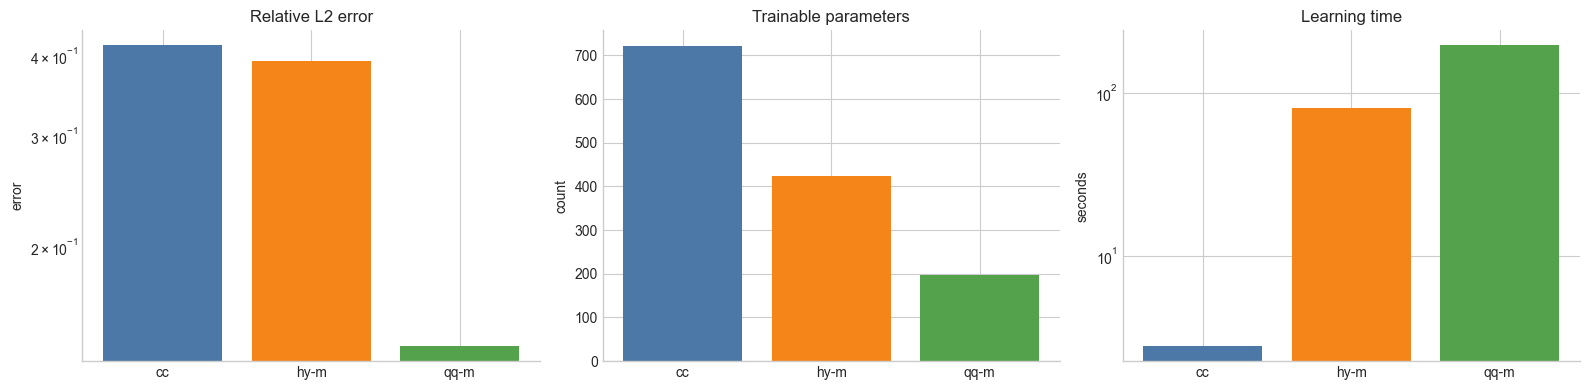

In [60]:
latest_runs = latest_runs_for_models(SUMMARY_PATH, TARGET_MODELS)
if len(latest_runs) != len(TARGET_MODELS):
    raise RuntimeError(f"Expected runs for {TARGET_MODELS}, found {[row['model'] for row in latest_runs]}")

labels = [str(row["model"]) for row in latest_runs]
params = [int(row["params"]) for row in latest_runs]
times = [float(row["elapsed"]) for row in latest_runs]
errors = [float(row["rel_l2"]) for row in latest_runs]
colors = [family_color(label) for label in labels]

print("Latest DHO runs used in this notebook")
print("-" * 88)
print(f"{'model':>8} | {'size':>8} | {'params':>10} | {'rel_l2':>12} | {'time_s':>10} | {'run_id':>15}")
print("-" * 88)
for row in latest_runs:
    print(
        f"{str(row['model']):>8} | {str(row['size']):>8} | {int(row['params']):10d} | "
        f"{float(row['rel_l2']):12.4e} | {float(row['elapsed']):10.2f} | {str(row['run_id']):>15}"
    )

best_error = labels[int(np.argmin(errors))]
smallest_model = labels[int(np.argmin(params))]
fastest_model = labels[int(np.argmin(times))]
print()
print(f"Lowest relative L2 error : {best_error}")
print(f"Smallest model            : {smallest_model}")
print(f"Fastest training          : {fastest_model}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(labels, errors, color=colors)
axes[0].set_title("Relative L2 error")
axes[0].set_ylabel("error")
axes[0].set_yscale("log")

axes[1].bar(labels, params, color=colors)
axes[1].set_title("Trainable parameters")
axes[1].set_ylabel("count")

axes[2].bar(labels, times, color=colors)
axes[2].set_title("Learning time")
axes[2].set_ylabel("seconds")
axes[2].set_yscale("log")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()


## 5. Qualitative Trajectory Comparison

Scalar metrics are informative, but they do not fully characterize the predicted dynamics.
The final figure therefore complements the summary table by displaying the final saved trajectory for each retained variant.


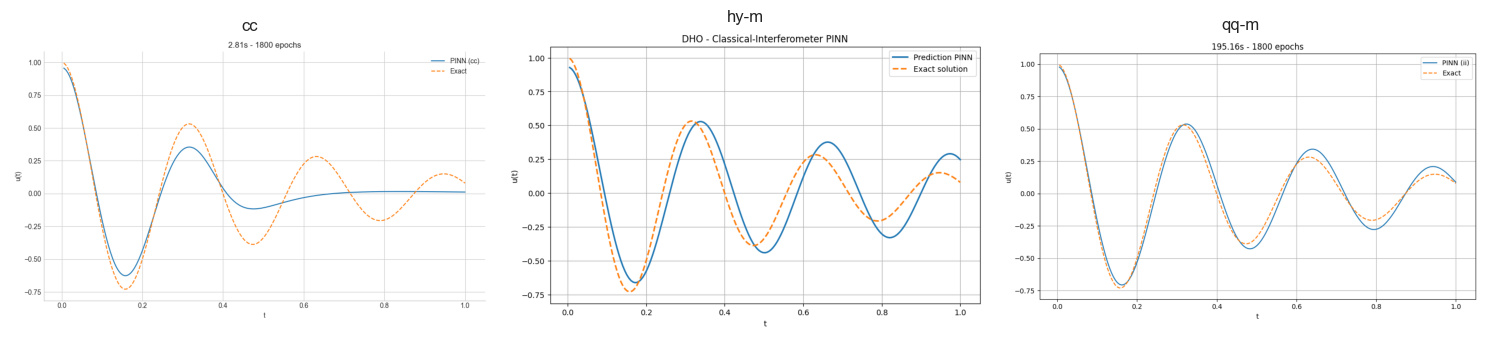

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, model in zip(axes, TARGET_MODELS):
    image_path = final_png_for(model)
    if image_path is None:
        ax.set_title(f"{model}: no png found")
        ax.axis("off")
        continue
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.set_title(model)
    ax.axis("off")

fig.tight_layout()
plt.show()
